##      Accident Risk Prediction Using XGBoost



## 📦 Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


## 📂 Loading the Dataset

In [2]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')

## 👀 Preview of Training Data

In [3]:
## 👀 Preview of Training Data

## ℹ️ Dataset Information

In [4]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

## 🧩 Dataset Overview


In [5]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)


Train shape: (517754, 14)
Test shape: (172585, 13)
Train columns: Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')
Test columns: Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents'],
      dtype='object')


## 🔍 Feature Classification

In [6]:
features   = train_df.drop(columns=['accident_risk','id']).columns
target = train_df['accident_risk']
num_features = train_df[features].select_dtypes(include=['int64', 'float64']).columns
cat_features = train_df[features].select_dtypes(include=['object', 'category']).columns
bin_features = train_df[features].select_dtypes(include=['bool']).columns
cat_features = cat_features.append(bin_features)
print("Numerical features:", num_features)
print("Categorical features:", cat_features)
print("Binary features:", bin_features)
print("Number of numerical features:", len(num_features))
print("Number of categorical features:", len(cat_features))
print("Number of binary features:", len(bin_features))

Numerical features: Index(['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents'], dtype='object')
Categorical features: Index(['road_type', 'lighting', 'weather', 'time_of_day', 'road_signs_present',
       'public_road', 'holiday', 'school_season'],
      dtype='object')
Binary features: Index(['road_signs_present', 'public_road', 'holiday', 'school_season'], dtype='object')
Number of numerical features: 4
Number of categorical features: 8
Number of binary features: 4


## 🔁 Checking for Duplicate Rows

In [7]:
train_df.duplicated().sum()

0

## 📊 Distribution of Numerical Features

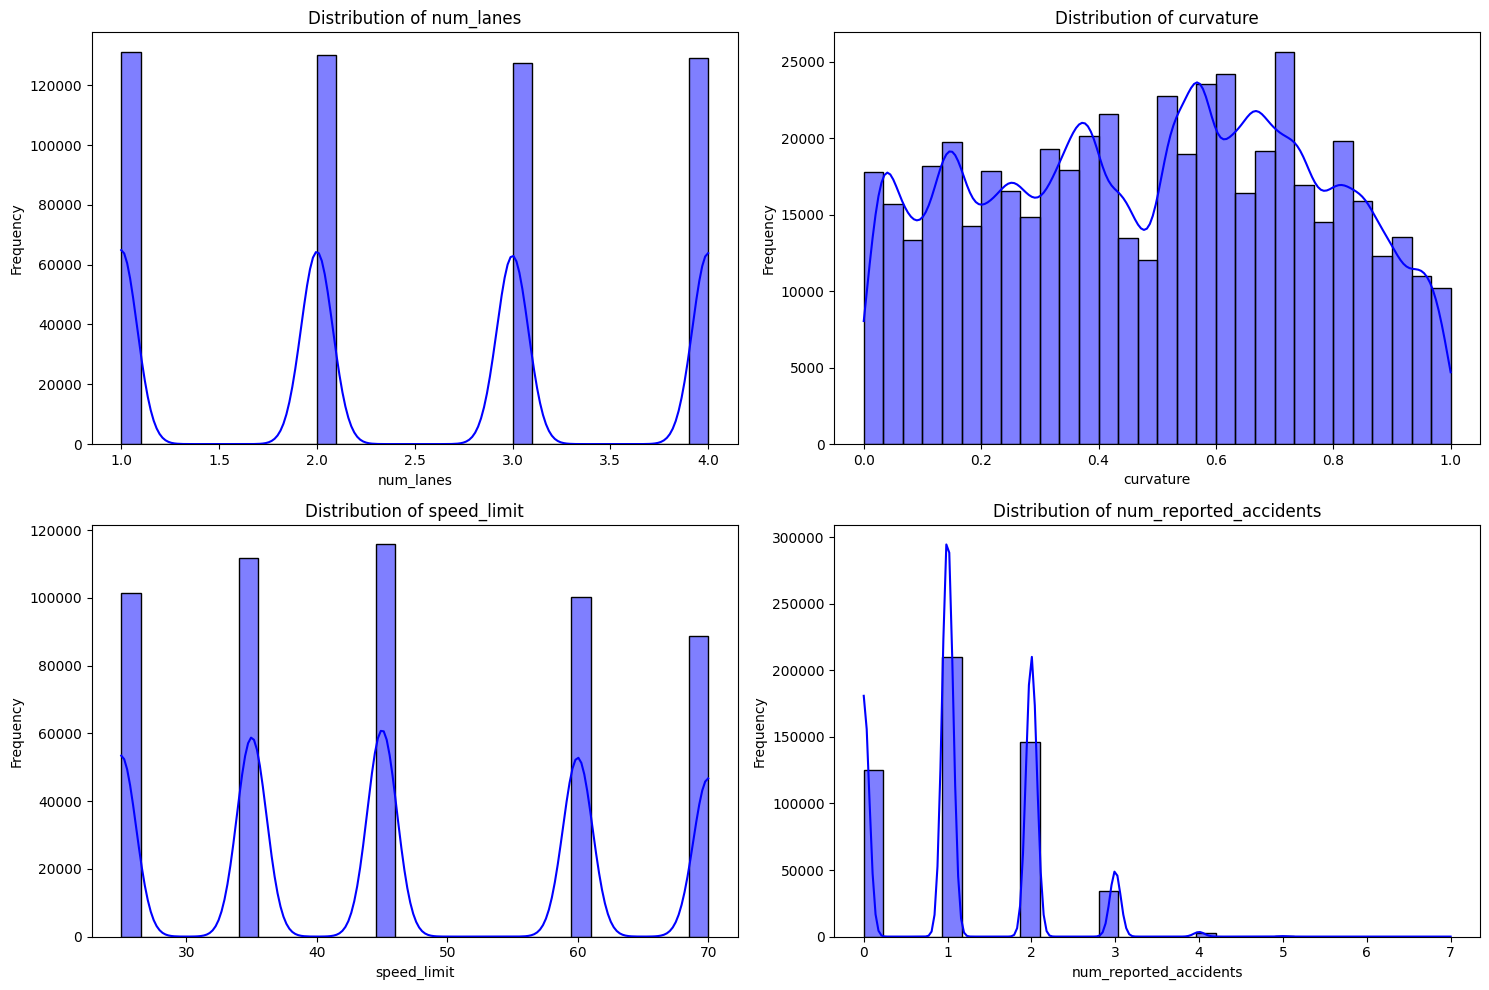

In [8]:
# plt the distrubution of the numerical data
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(num_features):
    ax = axs[i // 2, i % 2]
    sns.histplot(train_df[col], bins=30, kde=True, color='blue', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 🧮 Distribution of Categorical Features

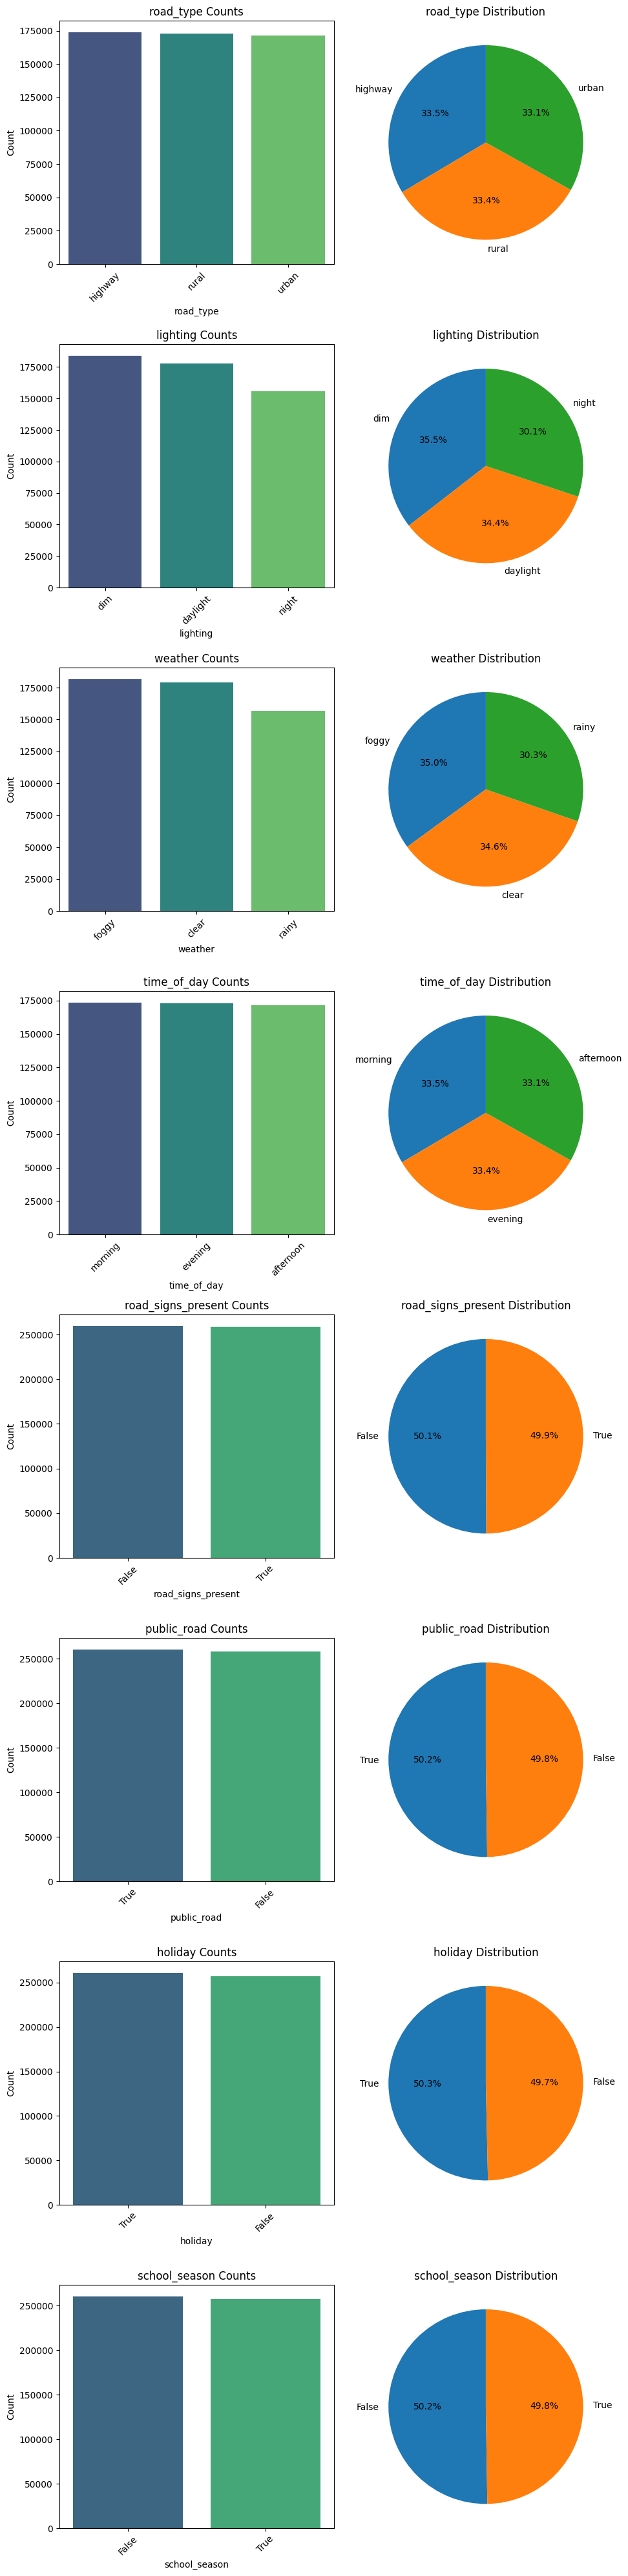

In [9]:
# Plot distribution of categorical data
fig, axs = plt.subplots(len(cat_features), 2, figsize=(10, 5 * len(cat_features)))
for i, col in enumerate(cat_features):
    if col in train_df.columns:
        sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index, palette='viridis', ax=axs[i, 0])
        axs[i, 0].set_title(f'{col} Counts')
        axs[i, 0].set_xlabel(col)
        axs[i, 0].set_ylabel('Count')
        axs[i, 0].tick_params(axis='x', rotation=45)

        # Plot the percentage on the right subplot
        axs[i, 1].pie(train_df[col].value_counts(), labels=train_df[col].value_counts().index, autopct='%1.1f%%', startangle=90)
        axs[i, 1].set_title(f'{col} Distribution')
    else:
        axs[i, 0].text(0.5, 0.5, f'Column {col} not found', ha='center', va='center')
        axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 🎯 Target Variable Analysis

The information of the target variable is:
<class 'pandas.core.series.Series'>
RangeIndex: 517754 entries, 0 to 517753
Series name: accident_risk
Non-Null Count   Dtype  
--------------   -----  
517754 non-null  float64
dtypes: float64(1)
memory usage: 4.0 MB
None
The description of the target variable is:
count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64
The number of unique values in the target variable is: 98


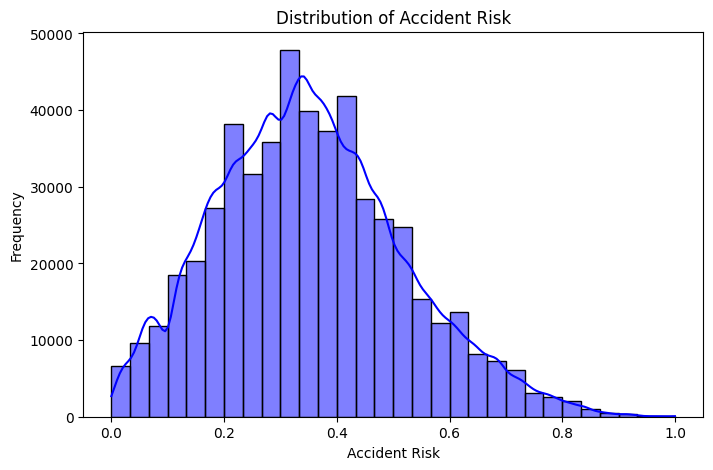

In [10]:
print("The information of the target variable is:")
print(train_df["accident_risk"].info())
print("The description of the target variable is:")
print(train_df["accident_risk"].describe().T)
print("The number of unique values in the target variable is:", train_df["accident_risk"].nunique())

# plot the distrubution of target variable
plt.figure(figsize=(8,5))
sns.histplot(train_df['accident_risk'], bins=30, kde=True, color='blue')
plt.title('Distribution of Accident Risk')
plt.xlabel('Accident Risk')
plt.ylabel('Frequency')
plt.show()

In [11]:
train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 📈 Categorical Features vs Target Variable

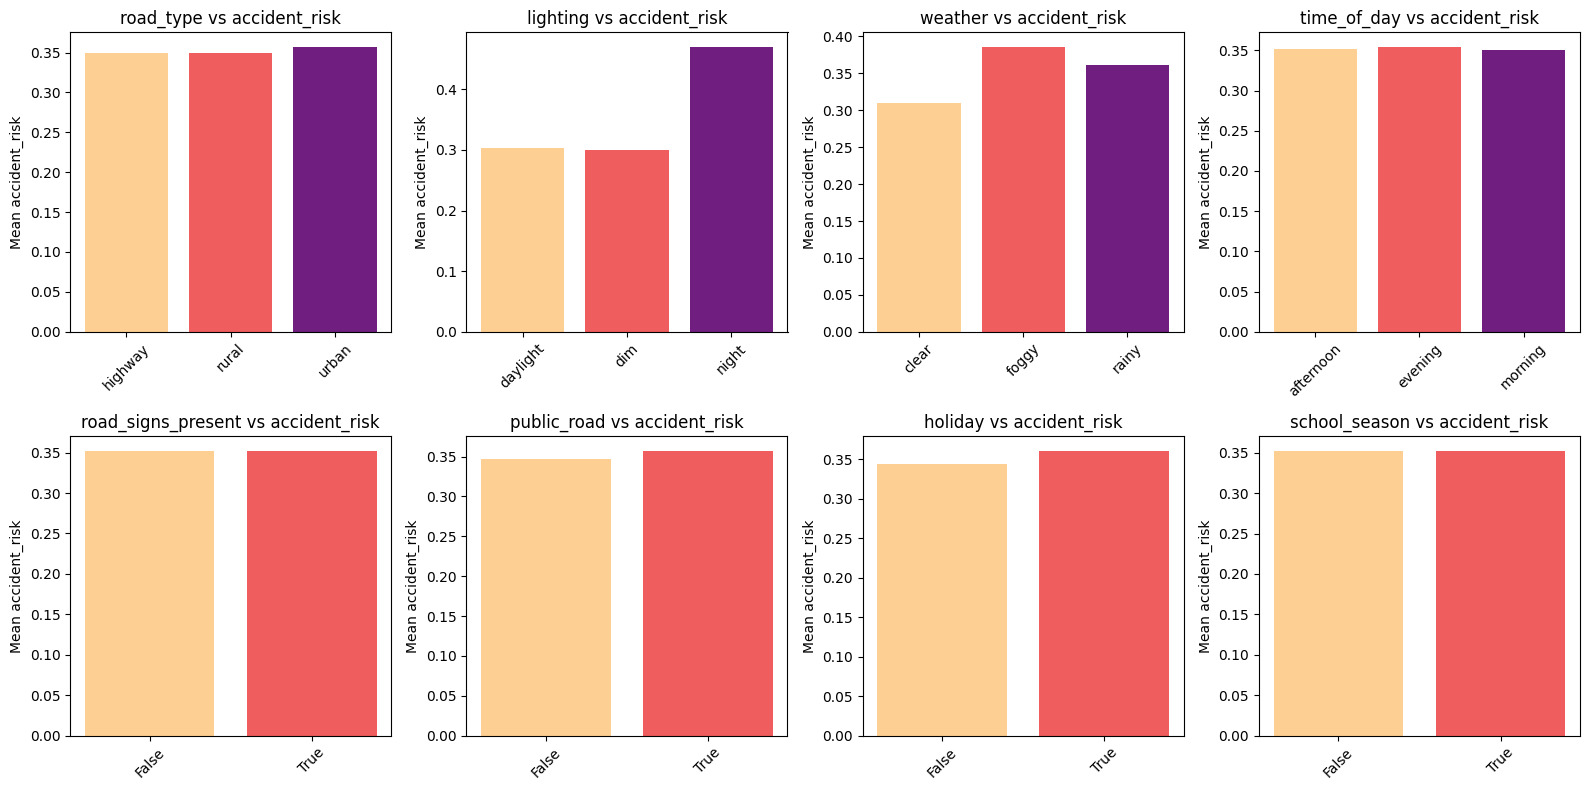

In [12]:
# Categorical features vs target

fig , axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()
cmap = plt.get_cmap('magma')
colors = cmap([0.9,0.66,0.33])
target = 'accident_risk'
for i,col in enumerate(cat_features) :

    grouped = train_df.groupby(col)[target].mean()

    axes[i].bar(grouped.index.astype(str), grouped.values , color=colors)  # .astype(str) to handle non-string indices
    
    axes[i].set_ylabel(f'Mean {target}')
    axes[i].set_title(f'{col} vs {target}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 🔗 Pairwise Relationships Between Numerical Features

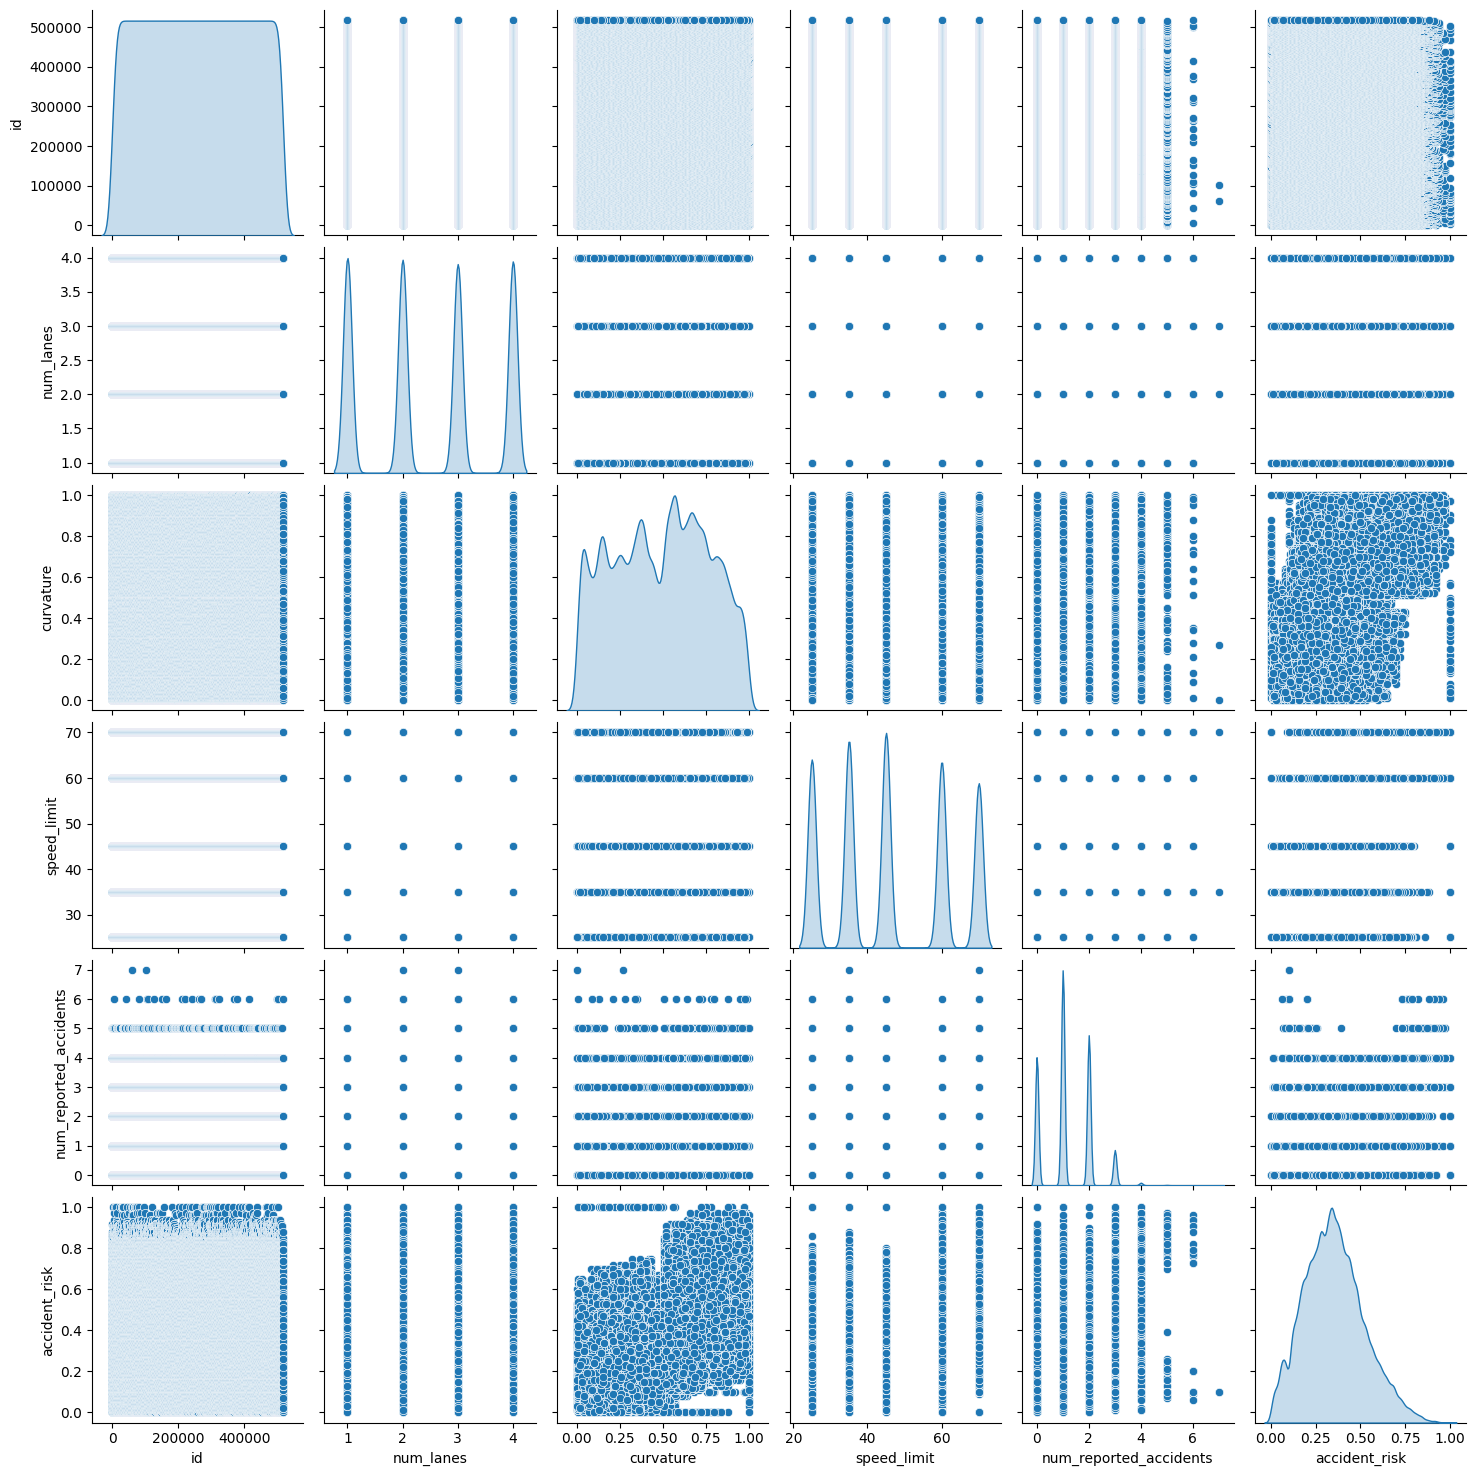

In [13]:
sns.pairplot(train_df.select_dtypes(include=['float64', 'int64']), diag_kind='kde')
plt.show()


# plt the correlation heatmap


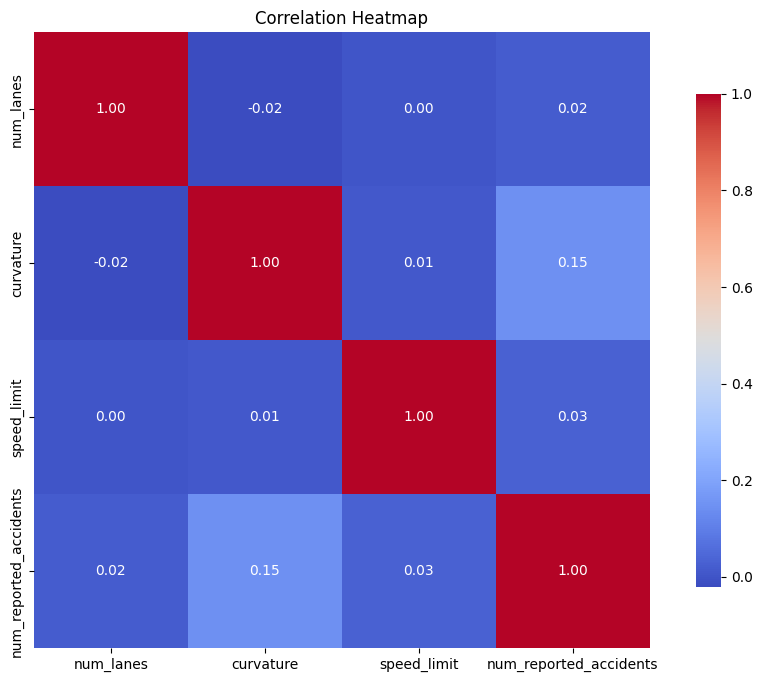

In [14]:
# plt the correlation heatmap
plt.figure(figsize=(12, 8))
corr = train_df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.show()

## ⚙️ Feature Separation for Preprocessing

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = train_df.drop(columns=['id', 'accident_risk'])
y = train_df['accident_risk']

num_feats = X.select_dtypes(include=['int64', 'float64']).columns
cat_feats = X.select_dtypes(include=['object', 'category','bool']).columns

print("Numerical features:", num_feats)
print("Categorical features:", cat_feats)



Numerical features: Index(['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents'], dtype='object')
Categorical features: Index(['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road',
       'time_of_day', 'holiday', 'school_season'],
      dtype='object')


## 🧩 Data Preprocessing and Splitting

In [16]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_feats),
        ('cat', categorical_transformer, cat_feats)
    ])
X_processed = preprocessor.fit_transform(X)
print("Processed feature shape:", X_processed.shape)

x_train, x_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print("Training set shape:", x_train.shape, y_train.shape)

Processed feature shape: (517754, 24)
Training set shape: (414203, 24) (414203,)


## 🚀 Model Training with XGBoost Regressor

In [17]:
from xgboost import XGBRegressor
param = {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'colsample_bylevel': 1.0,
        'colsample_bynode': 1.0,
        'gamma': 0.0,
        'reg_alpha': 0.0,      # L1 regularization
        'reg_lambda': 1.0,    # L2 regularization
        'min_child_weight': 1,
        'max_delta_step': 0,
        'scale_pos_weight': 1.0,
        'tree_method': 'hist',
        'booster': 'gbtree',
        'sampling_method': 'uniform',
        'random_state': 42,
        'verbosity': 0

}
model = XGBRegressor(**param)
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=1.0, colsample_bynode=1.0, colsample_bytree=0.8,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=0, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

## 📊 Model Evaluation Metrics


In [18]:
# mean_square,r2,amse,
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred = model.predict(x_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 0.003170601862115918
R^2 Score: 0.8851738535611934
Mean Absolute Error: 0.043718032275106865


## 🎯 Actual vs Predicted Values Plot

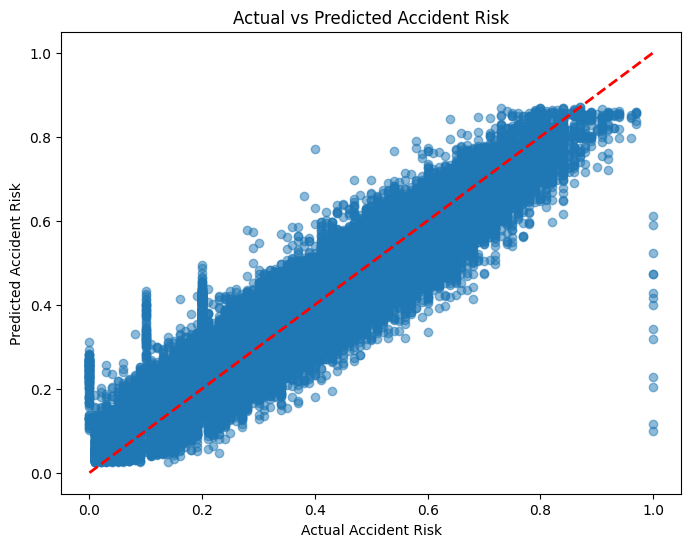

In [19]:
# plot the regrossr plot
plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Accident Risk')
plt.ylabel('Predicted Accident Risk')
plt.title('Actual vs Predicted Accident Risk')
plt.show()

## 🌟 XGBoost Feature Importance Visualization

                  Feature  Importance
0               curvature      1878.0
1  num_reported_accidents       846.0
2           weather_clear       496.0
3             speed_limit       418.0
4          lighting_night       316.0
5               num_lanes       308.0
6           holiday_False       268.0
7       public_road_False       198.0
8           weather_rainy       193.0
9           weather_foggy       184.0


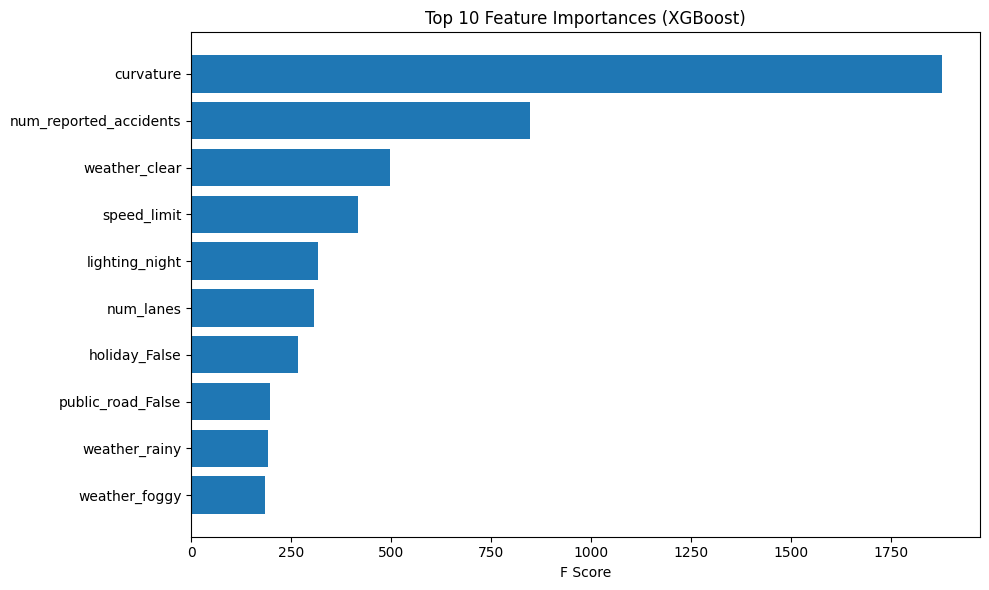

In [20]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Make sure your model is already fitted
# model.fit(x_train, y_train)

# Extract feature importances
booster = model.get_booster()
importance = booster.get_score(importance_type='weight')  # or 'gain', 'cover'


# Plot top features
plt.figure(figsize=(10, 6))
# Build human-readable feature names from the fitted preprocessor
num_cols = list(preprocessor.transformers_[0][2])  # numeric original names
cat_cols = list(preprocessor.transformers_[1][2])  # categorical original names

# get the fitted OneHotEncoder inside the pipeline
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_ohe_names = list(ohe.get_feature_names_out(cat_cols))

feature_names = num_cols + cat_ohe_names  # final feature names in the same order as X_processed

# Map XGBoost importance keys ('f0', 'f1', ...) to these feature names
items = []
for k, v in importance.items():
    idx = int(k[1:])  # drop leading 'f' and convert to int
    name = feature_names[idx] if idx < len(feature_names) else f'f{idx}'
    items.append((idx, name, v))

importance_df = pd.DataFrame(items, columns=['Index', 'Feature', 'Importance']).sort_values('Importance', ascending=False).reset_index(drop=True)

# show the top 10 with original feature names
print(importance_df[['Feature', 'Importance']].head(10))

# Plot top 10 features (use original names)
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.xlabel('F Score')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()




## 📤 Preparing Test Data & Generating Submission File

In [21]:

cat_features = test_df.select_dtypes(include=['object', 'category','bool']).columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
test_cat_encoded = encoder.fit_transform(test_df[cat_features])
test_df[num_feats] = StandardScaler().fit_transform(test_df[num_feats])
test_df_encoded = np.hstack((test_df[num_feats].values, test_cat_encoded))
y_pred_test = model.predict(test_df_encoded)
submission_df = pd.read_csv('/kaggle/input/playground-series-s5e10/sample_submission.csv')
submission_df['accident_risk'] = y_pred_test
submission_df.to_csv('submission.csv', index=False)


## 🏁 Conclusion

In this notebook, we explored, preprocessed, and modeled the **Playground Series S5E10** dataset to predict `accident_risk`.  
Here’s a summary of the workflow and key takeaways:

- **Data Exploration:**  
  We examined the structure of the dataset, identified numerical and categorical features, and visualized their distributions.  
  Correlation analysis helped us understand relationships between variables.

- **Preprocessing:**  
  Using a `ColumnTransformer`, we applied `StandardScaler` for numerical features and `OneHotEncoder` for categorical ones.  
  This ensured that the model handled diverse data types effectively.

- **Modeling:**  
  We trained an **XGBoost Regressor**, a powerful gradient boosting algorithm known for its performance and interpretability.  
  Model evaluation with metrics like **MSE**, **MAE**, and **R²** confirmed that it performed well on the validation set.

- **Feature Importance:**  
  By mapping XGBoost’s internal features (`f0`, `f1`, …) back to original names,  
  we visualized which variables contributed most to accident risk prediction.

- **Submission:**  
  The trained model was used to make predictions on the test set, and the results were saved as a CSV file (`submission.csv`)  
  for competition submission.

### ✅ Key Insight:
Feature engineering, preprocessing consistency, and model interpretability were crucial to achieving strong predictive performance.  
Future improvements could involve **hyperparameter tuning**, **feature selection**, or **ensemble methods** to further boost accuracy.
